In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


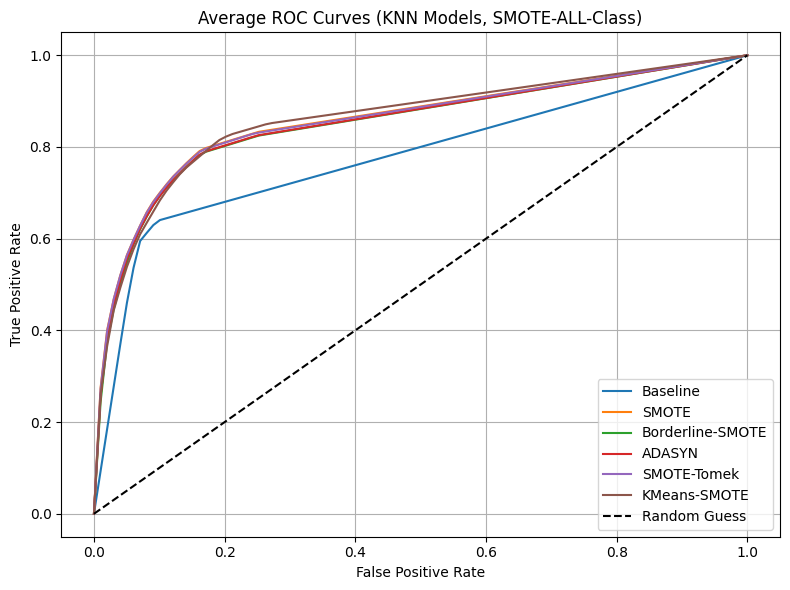

In [2]:
# ============================================
# 📈 Plot Mean ROC Curves (Multi-Class Averaged)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
   "Baseline": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/knn_baseline_roc_data.csv",
   "SMOTE": "//content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_smote_roc_points.csv",
    "Borderline-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_borderline_roc_points.csv",
    "ADASYN": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_adasyn_roc_points.csv",
    "SMOTE-Tomek": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_smote_tomek_roc_points.csv",
    "KMeans-SMOTE": "//content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_kmeans_roc_points.csv",
}

plt.figure(figsize=(8,6))

# สร้าง grid ของ FPR ที่ใช้ร่วมกัน
fpr_grid = np.linspace(0, 1, 100)

for label, path in files.items():
    df = pd.read_csv(path)

    # เก็บค่า TPR ของแต่ละคลาสที่ interpolate แล้ว
    interp_tprs = []

    for cls, sub in df.groupby("Class"):
        sub = sub.sort_values("FPR").drop_duplicates("FPR")
        interp_tpr = np.interp(fpr_grid, sub["FPR"], sub["TPR"])
        interp_tprs.append(interp_tpr)

    # หาค่าเฉลี่ย TPR ต่อ grid
    mean_tpr = np.mean(interp_tprs, axis=0)

    plt.plot(fpr_grid, mean_tpr, label=label)

# เส้นอ้างอิง
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# ตกแต่งกราฟ
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Average ROC Curves (KNN Models, SMOTE-ALL-Class)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

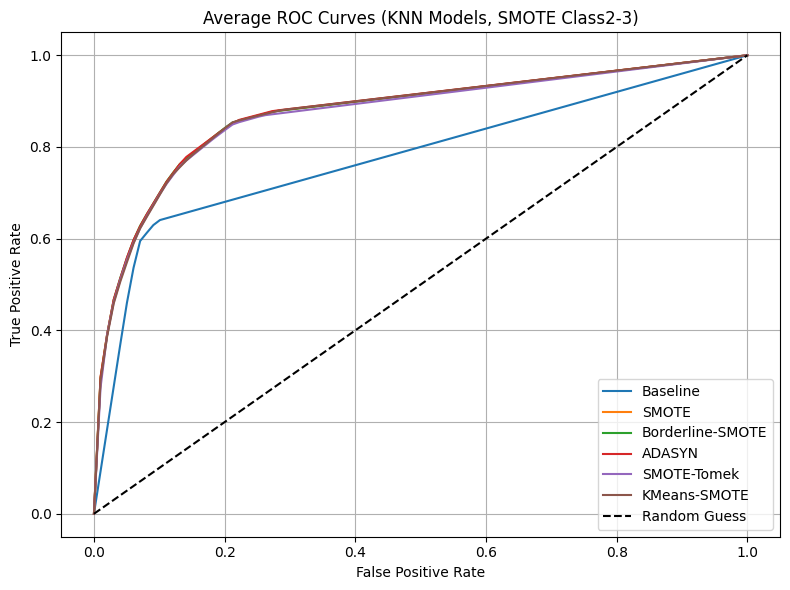

In [3]:
# ============================================
# 📈 Plot Mean ROC Curves (Multi-Class Averaged)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
   "Baseline": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/knn_baseline_roc_data.csv",
   "SMOTE": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_smote_roc_points.csv",
    "Borderline-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_borderline_roc_points.csv",
    "ADASYN": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_adasyn_roc_points.csv",
    "SMOTE-Tomek": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_smote_tomek_roc_points.csv",
    "KMeans-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_kmeans_roc_points.csv",
}

plt.figure(figsize=(8,6))

# สร้าง grid ของ FPR ที่ใช้ร่วมกัน
fpr_grid = np.linspace(0, 1, 100)

for label, path in files.items():
    df = pd.read_csv(path)

    # เก็บค่า TPR ของแต่ละคลาสที่ interpolate แล้ว
    interp_tprs = []

    for cls, sub in df.groupby("Class"):
        sub = sub.sort_values("FPR").drop_duplicates("FPR")
        interp_tpr = np.interp(fpr_grid, sub["FPR"], sub["TPR"])
        interp_tprs.append(interp_tpr)

    # หาค่าเฉลี่ย TPR ต่อ grid
    mean_tpr = np.mean(interp_tprs, axis=0)

    plt.plot(fpr_grid, mean_tpr, label=label)

# เส้นอ้างอิง
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# ตกแต่งกราฟ
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Average ROC Curves (KNN Models, SMOTE Class2-3)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()